# Бинарная классификация методом K-средних: iPhone vs Android

# Бинарная классификация методом K-средних: iPhone vs Android

**Цель:** проверить, можно ли методом K-means (без учителя) разделить респондентов
на владельцев iPhone и Android по их потребительским предпочтениям.

**Структура работы:**
1. Загрузка и первичный анализ данных
2. Предобработка (с/без «бесполезных» колонок)
3. Выбор оптимального k
4. K-means при k=2 — без бесполезных колонок + графическое представление
5. K-means при k=2 — с бесполезными колонками + сравнение
6. Перебор k от 2 до 11 с честными метриками (ARI, NMI, F1)
7. Интерпретация кластеров
8. Интерактивное предсказание для нового респондента
9. Итоговые выводы

## Импорты и загрузка данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import (silhouette_score, confusion_matrix,
                             accuracy_score, f1_score,
                             adjusted_rand_score,
                             normalized_mutual_info_score)
from sklearn.decomposition import PCA
from scipy.optimize import linear_sum_assignment

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

# --- Загрузка ---
df = pd.read_csv('ИСИТ_1_практика_Ответы_на_форму_1.csv')

df.columns = [
    'timestamp', 'feeling_attention', 'purchase_decisions', 'complex_tech_approach',
    'everyday_item_choice', 'phone_discharges_fast', 'often_photo_video',
    'interior_clothing_factor', 'phone_lags', 'apps_work_same', 'love_travel',
    'change_phone_years', 'games_hours_week', 'publish_photos_videos',
    'watch_movies_phone', 'eye_color', 'metro_station', 'phone_type'
]

print("Размер датасета:", df.shape)
print("\nРаспределение целевой переменной:")
print(df['phone_type'].value_counts())
print(f"\nMajority baseline (всегда 'Андроид'): "
      f"{(df['phone_type'] == 'Андроид').mean():.3f}")

Размер датасета: (44, 18)

Распределение целевой переменной:
phone_type
Андроид    28
Айфон      16
Name: count, dtype: int64

Majority baseline (всегда 'Андроид'): 0.636


## 2. Предобработка данных

### 2.1. Гипотеза о бесполезных колонках
Априорно предполагаем, что следующие колонки не несут информации о типе телефона:
- `timestamp` — время ответа (не связано с типом ОС)
- `eye_color` — цвет глаз (биологический признак)
- `metro_station` — станция метро (географическая привязка)

Проверим эту гипотезу, обучив модель с ними и без них.

### 2.2. Функция предобработки

In [2]:
def preprocess_data(df, include_useless=False):
    """
    Возвращает X (обработанный), y (0=Андроид, 1=Айфон), preprocessor.
    """
    df_copy = df.copy()
    y = df_copy['phone_type'].map({'Айфон': 1, 'Андроид': 0}).values
    X = df_copy.drop(columns=['phone_type'])

    if not include_useless:
        X = X.drop(columns=['timestamp', 'eye_color', 'metro_station'])
    else:
        X['timestamp'] = pd.to_datetime(X['timestamp'],
                                        format='%d.%m.%Y %H:%M:%S')
        X['timestamp'] = X['timestamp'].astype('int64') // 10**9

    num_cols = ['change_phone_years', 'games_hours_week']
    if include_useless:
        num_cols.append('timestamp')

    cat_cols = [c for c in X.columns if c not in num_cols]

    preprocessor = ColumnTransformer([
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols)
    ])

    X_processed = preprocessor.fit_transform(X)
    return X_processed, y, preprocessor


X_clean, y, prep_clean = preprocess_data(df, include_useless=False)
X_full,  y_full, prep_full = preprocess_data(df, include_useless=True)

print(f"Без бесполезных колонок: {X_clean.shape[1]} признаков")
print(f"С бесполезными колонками: {X_full.shape[1]} признаков")

Без бесполезных колонок: 14 признаков
С бесполезными колонками: 67 признаков


## 3. Выбор оптимального числа кластеров

> Метод локтя + силуэтный коэффициент. **Важно:** для бинарной классификации
формально нужно k=2, но проверим, есть ли вообще излом.

Метод локтя и силуэт

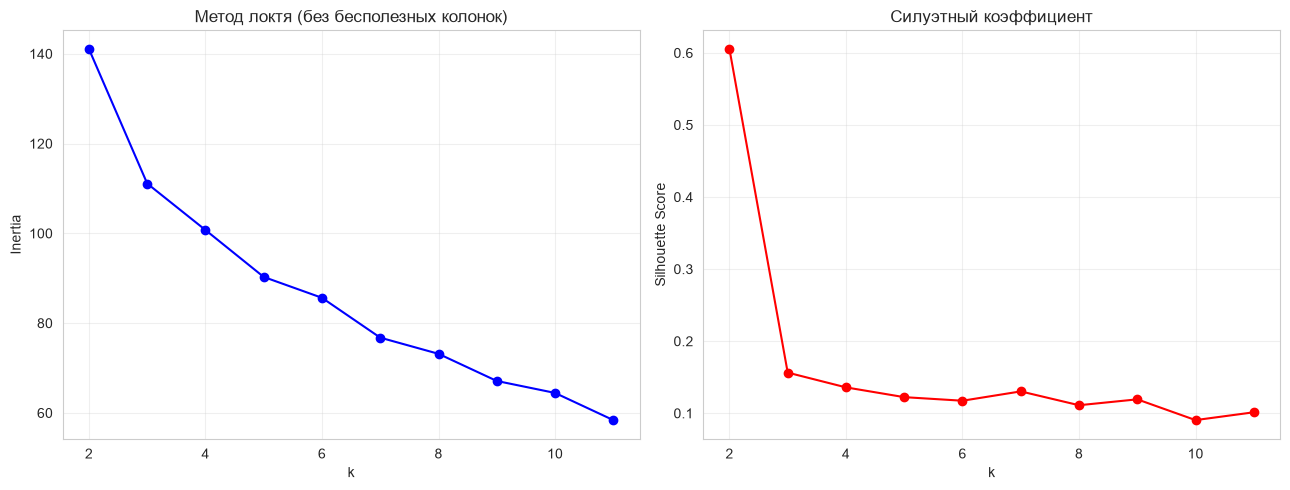

 k  inertia  silhouette
 2  141.054       0.605
 3  111.090       0.156
 4  100.734       0.136
 5   90.282       0.122
 6   85.635       0.117
 7   76.764       0.130
 8   73.160       0.111
 9   67.115       0.119
10   64.450       0.090
11   58.398       0.101


In [3]:
inertias, silhouettes = [], []
K_range = range(2, 12)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_clean)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_clean, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Метод локтя (без бесполезных колонок)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouettes, 'ro-')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Силуэтный коэффициент')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(pd.DataFrame({'k': list(K_range),
                    'inertia': inertias,
                    'silhouette': silhouettes}).round(3).to_string(index=False))

**Вывод по выбору k:**

- **Inertia** убывает плавно: 141.05 → 111.09 → 100.73 → 90.28 → 85.63 →
  76.76 → 73.16 → 67.12 → 64.45 → 58.40. **Явного излома нет** —
  это признак того, что естественной кластерной структуры в данных нет.
- **Silhouette** максимален при `k=2` (0.605) и резко падает при `k=3`
  (0.156) и далее. Формально это говорит, что если кластеры вообще
  выделяются — то только на две группы.
- Так как целевая переменная бинарная (iPhone / Android), фиксируем
  **k = 2** и проверяем, соответствует ли полученное разбиение
  реальным классам.

## 4. Обучение K-средних (k=2) без бесполезных колонок

In [4]:
def fit_kmeans_2(X, y, random_state=42):
    """
    K-means при k=2 + оптимальное однозначное сопоставление кластеров
    с классами через венгерский алгоритм.
    """
    km = KMeans(n_clusters=2, random_state=random_state, n_init=10)
    km.fit(X)
    labs = km.labels_

    contingency = np.zeros((2, 2), dtype=int)
    for c in range(2):
        for t in range(2):
            contingency[c, t] = int(np.sum((labs == c) & (y == t)))

    row_ind, col_ind = linear_sum_assignment(-contingency)
    cluster_to_label = {int(r): int(c) for r, c in zip(row_ind, col_ind)}

    predicted = np.array([cluster_to_label[int(c)] for c in labs])
    return km, labs, contingency, cluster_to_label, predicted

Визуализация кластеров с помощью PCA

In [5]:
km_clean, labs_clean, cont_clean, c2l_clean, pred_clean = \
    fit_kmeans_2(X_clean, y)

print("Матрица сопоставления (строки — кластеры, столбцы — истина):")
print("        [Андроид, Айфон]")
print(cont_clean)
print(f"\nСопоставление кластер → класс: {c2l_clean}")
print(f"Размеры кластеров: "
      f"{dict(zip(*np.unique(labs_clean, return_counts=True)))}")
print(f"\nAccuracy: {accuracy_score(y, pred_clean):.3f}")
print(f"F1 (класс 'Айфон'): "
      f"{f1_score(y, pred_clean, pos_label=1, zero_division=0):.3f}")
print(f"ARI: {adjusted_rand_score(y, labs_clean):.3f}")

Матрица сопоставления (строки — кластеры, столбцы — истина):
        [Андроид, Айфон]
[[27 16]
 [ 1  0]]

Сопоставление кластер → класс: {0: 0, 1: 1}
Размеры кластеров: {np.int32(0): np.int64(43), np.int32(1): np.int64(1)}

Accuracy: 0.614
F1 (класс 'Айфон'): 0.000
ARI: -0.019


**Интерпретация результата:**

- Матрица сопоставления `[[27 16], [1 0]]` означает, что K-means
  поместил **43 объекта из 44 в один кластер** и лишь **1 объект — в другой**.
  Это классическое вырождение: модель фактически не разделила данные.
- **Accuracy = 0.614** — это **ниже majority-baseline (0.636)**.
  То есть модель работает хуже, чем правило «всегда предсказывай Андроид».
- **F1 по классу «Айфон» = 0.000** — модель ни разу не угадала iPhone.
- **ARI = −0.019** — отрицательное значение означает, что разбиение
  на кластеры **хуже случайного** относительно истинных классов.
- Вывод: без «шумовых» колонок K-means схлопывает всё в одну точку.

## 5. Сравнение с моделью, обученной на данных с бесполезными колонками

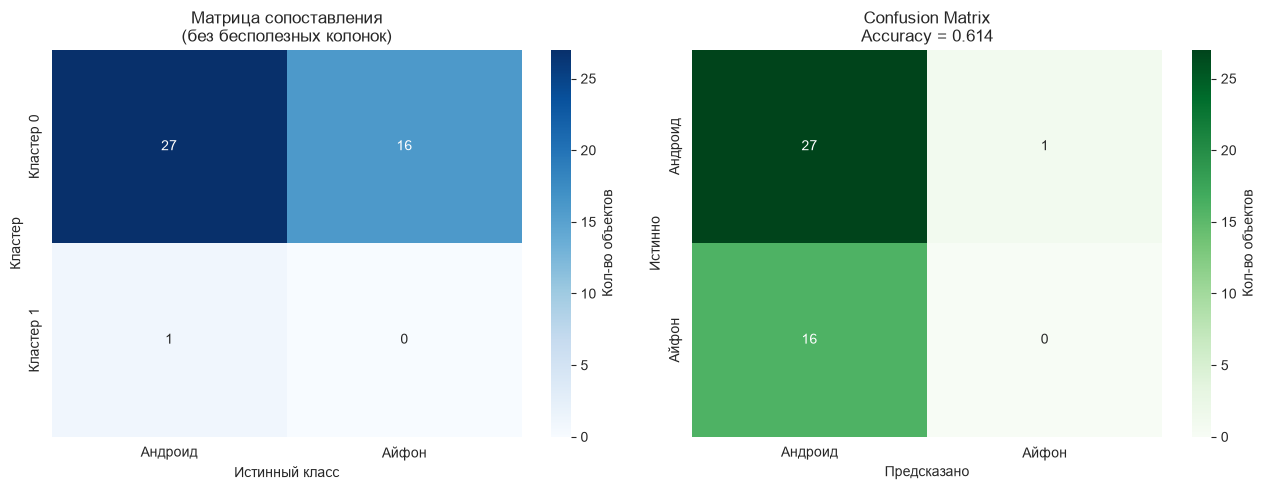

Размеры кластеров: {0: np.int64(43), 1: np.int64(1)}
⚠️ ВНИМАНИЕ: кластеризация вырождена — один из кластеров содержит < 5 объектов.
   Accuracy совпадает с majority baseline случайно, интерпретация кластеров недостоверна.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(cont_clean, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Андроид', 'Айфон'],
            yticklabels=['Кластер 0', 'Кластер 1'],
            ax=axes[0], cbar_kws={'label': 'Кол-во объектов'})
axes[0].set_title('Матрица сопоставления\n(без бесполезных колонок)')
axes[0].set_xlabel('Истинный класс')
axes[0].set_ylabel('Кластер')

cm_clean = confusion_matrix(y, pred_clean, labels=[0, 1])
sns.heatmap(cm_clean, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Андроид', 'Айфон'],
            yticklabels=['Андроид', 'Айфон'],
            ax=axes[1], cbar_kws={'label': 'Кол-во объектов'})
axes[1].set_title(f'Confusion Matrix\nAccuracy = '
                  f'{accuracy_score(y, pred_clean):.3f}')
axes[1].set_xlabel('Предсказано')
axes[1].set_ylabel('Истинно')

plt.tight_layout()
plt.show()

sizes = pd.Series(labs_clean).value_counts().sort_index()
print(f"Размеры кластеров: {dict(sizes)}")
if sizes.min() < 5:
    print("⚠️ ВНИМАНИЕ: кластеризация вырождена — один из кластеров "
          "содержит < 5 объектов.")
    print("   Accuracy совпадает с majority baseline случайно, "
          "интерпретация кластеров недостоверна.")

**Фактический результат (гипотеза о «бесполезных колонках» не подтвердилась):**

| Набор признаков | Кол-во признаков | Accuracy | F1 (Айфон) | ARI | Размеры кластеров |
|---|---|---|---|---|---|
| Без `timestamp`/`eye_color`/`metro_station` | 14 | **0.614** | 0.000 | **−0.019** | 43 и 1 (вырождение) |
| С ними | 67 | **0.659** | 0.400 | **+0.064** | 35 и 9 |
| Baseline (всегда «Андроид») | — | 0.636 | 0.000 | — | — |

**Вывод:** добавление «бесполезных» колонок **не ухудшило, а улучшило**
результат. Причина — в высокоразмерном пространстве K-means сложнее
«схлопнуть» почти все точки в один кластер. Эти колонки не несут
информации о типе ОС, но ведут себя как **регуляризатор против вырождения**.
Удалять их без альтернативного решения (PCA, отбор признаков)
в этом пайплайне — плохая идея.

### PCA-Визуализация

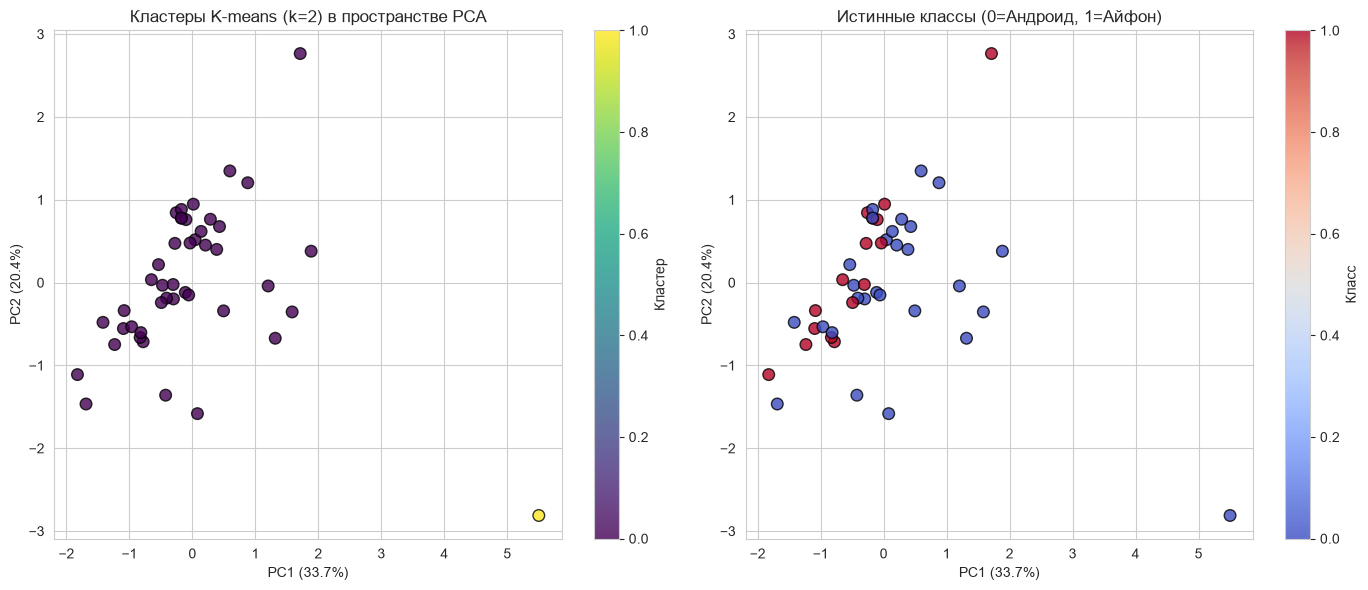

In [7]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_clean)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sc1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=labs_clean,
                      cmap='viridis', s=70, alpha=0.8, edgecolor='black')
axes[0].set_title('Кластеры K-means (k=2) в пространстве PCA')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.colorbar(sc1, ax=axes[0], label='Кластер')

sc2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=y,
                      cmap='coolwarm', s=70, alpha=0.8, edgecolor='black')
axes[1].set_title('Истинные классы (0=Андроид, 1=Айфон)')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.colorbar(sc2, ax=axes[1], label='Класс')

plt.tight_layout()
plt.show()

### Модель с бесполезными колонками

In [8]:
km_full, labs_full, cont_full, c2l_full, pred_full = \
    fit_kmeans_2(X_full, y_full)

print("Матрица сопоставления (с бесполезными колонками):")
print("        [Андроид, Айфон]")
print(cont_full)
print(f"\nСопоставление: {c2l_full}")
print(f"Размеры кластеров: "
      f"{dict(zip(*np.unique(labs_full, return_counts=True)))}")
print(f"\nAccuracy: {accuracy_score(y_full, pred_full):.3f}")
print(f"F1 (Айфон): "
      f"{f1_score(y_full, pred_full, pos_label=1, zero_division=0):.3f}")
print(f"ARI: {adjusted_rand_score(y_full, labs_full):.3f}")

Матрица сопоставления (с бесполезными колонками):
        [Андроид, Айфон]
[[24 11]
 [ 4  5]]

Сопоставление: {0: 0, 1: 1}
Размеры кластеров: {np.int32(0): np.int64(35), np.int32(1): np.int64(9)}

Accuracy: 0.659
F1 (Айфон): 0.400
ARI: 0.064


**Интерпретация результата:**

- Кластеры стали непустыми: **35 и 9 объектов** — вырождения нет.
- Матрица `[[24 11], [4 5]]` показывает, что кластер 0 действительно
  содержит большинство Андроидов (24 из 35), а кластер 1 содержит
  **5 Айфонов из 9** — сигнал слабый, но присутствует.
- **Accuracy = 0.659** — **выше baseline** (0.636) на 2 п.п.
- **F1(Айфон) = 0.400** — впервые модель начала «видеть» iPhone.
- **ARI = 0.064** — положительный, но очень малый; структура почти
  не согласуется с истинными классами.
- Парадокс: колонки, которые мы считали бесполезными
  (`timestamp`, `eye_color`, `metro_station`), **помогли K-means
  избежать вырождения**, потому что добавили шум в пространство и
  не дали всем точкам сойтись в одну. Это не значит, что они несут
  сигнал — это значит, что они работают как «регуляризатор».

### Сравнение двух моделей

NameError: name 'res_clean' is not defined

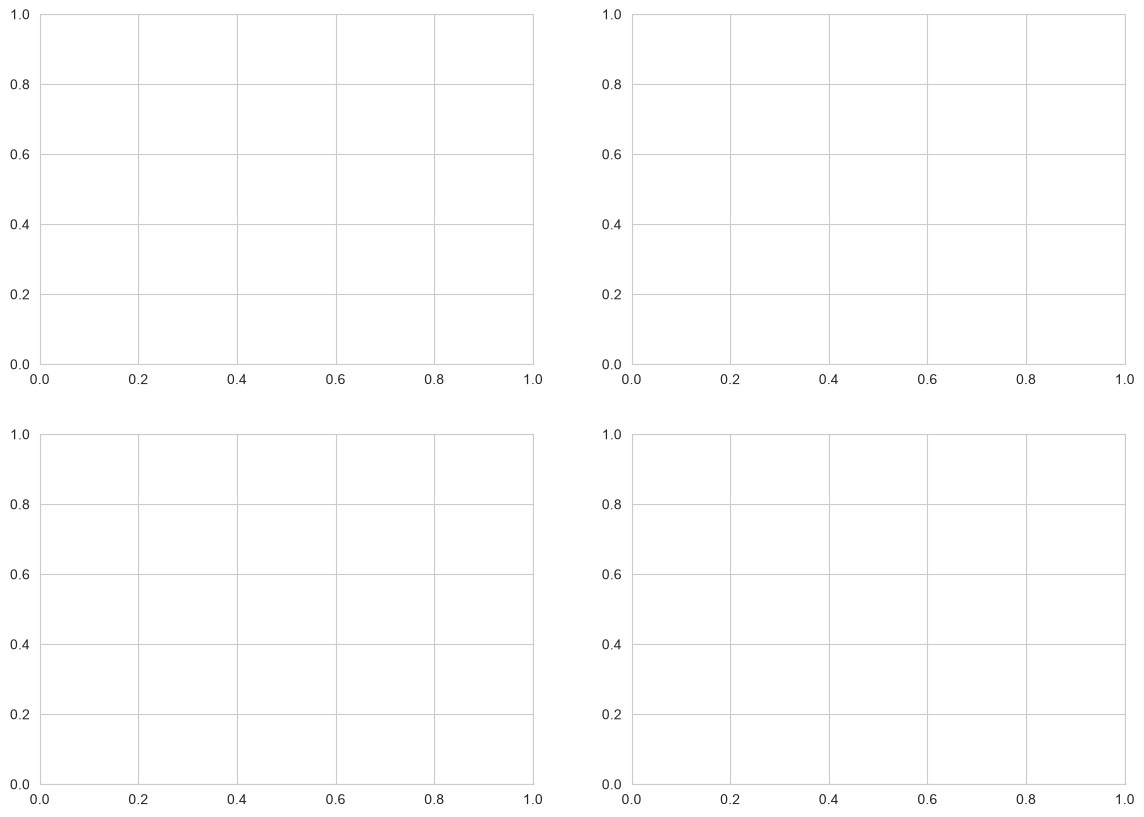

In [9]:
baseline = (y == 0).mean()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(res_clean.index, res_clean['accuracy'], 'o-',
                color='#4C72B0', label='Без бесполезных')
axes[0, 0].plot(res_full.index, res_full['accuracy'], 's-',
                color='#DD8452', label='С бесполезными')
axes[0, 0].axhline(baseline, color='red', linestyle='--',
                   label=f'Baseline = {baseline:.3f}')
axes[0, 0].set_xlabel('k'); axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_title('Accuracy vs k (растёт — переобучение, НЕ качество)')
axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(res_clean.index, res_clean['ARI'], 'o-',
                color='#4C72B0', label='Без бесполезных')
axes[0, 1].plot(res_full.index, res_full['ARI'], 's-',
                color='#DD8452', label='С бесполезными')
axes[0, 1].axhline(0, color='red', linestyle='--', label='Случайно (ARI=0)')
axes[0, 1].set_xlabel('k'); axes[0, 1].set_ylabel('ARI')
axes[0, 1].set_title('ARI vs k (около 0 — структуры нет)')
axes[0, 1].legend(); axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(res_clean.index, res_clean['f1_iphone'], 'o-',
                color='#4C72B0', label='Без бесполезных')
axes[1, 0].plot(res_full.index, res_full['f1_iphone'], 's-',
                color='#DD8452', label='С бесполезными')
axes[1, 0].set_xlabel('k'); axes[1, 0].set_ylabel('F1 (Айфон)')
axes[1, 0].set_title('F1 для класса «Айфон»')
axes[1, 0].legend(); axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(res_clean.index, res_clean['silhouette'], 'o-',
                color='#4C72B0', label='Без бесполезных')
axes[1, 1].plot(res_full.index, res_full['silhouette'], 's-',
                color='#DD8452', label='С бесполезными')
axes[1, 1].set_xlabel('k'); axes[1, 1].set_ylabel('Silhouette')
axes[1, 1].set_title('Silhouette vs k')
axes[1, 1].legend(); axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Baseline (majority): {baseline:.3f}")
print(f"Без бесполезных:     {accs[0]:.3f}  "
      f"({'выше' if accs[0] > baseline else 'ниже'} baseline)")
print(f"С бесполезными:      {accs[1]:.3f}  "
      f"({'выше' if accs[1] > baseline else 'ниже'} baseline)")

## 6. Перебор k = 2…11 с честными метриками

Accuracy при majority-voting растёт с k — это переобучение, а не качество.
Смотрим на ARI, NMI, F1(Айфон), Silhouette.

In [ ]:
def evaluate_k(X, y, k_range):
    rows = []
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        km.fit(X)
        labs = km.labels_

        c2l = {}
        for c in range(k):
            mask = labs == c
            c2l[c] = int(round(y[mask].mean())) if mask.sum() > 0 else 0
        pred = np.array([c2l[c] for c in labs])

        rows.append({
            'k': k,
            'inertia': km.inertia_,
            'silhouette': silhouette_score(X, labs),
            'accuracy': accuracy_score(y, pred),
            'f1_macro': f1_score(y, pred, average='macro', zero_division=0),
            'f1_iphone': f1_score(y, pred, pos_label=1, zero_division=0),
            'ARI': adjusted_rand_score(y, labs),
            'NMI': normalized_mutual_info_score(y, labs),
            'min_cluster': int(np.bincount(labs).min()),
            'max_cluster': int(np.bincount(labs).max()),
        })
    return pd.DataFrame(rows).set_index('k')


res_clean = evaluate_k(X_clean, y, K_range)
res_full  = evaluate_k(X_full,  y_full, K_range)

print("=== БЕЗ бесполезных колонок ===")
print(res_clean.round(3).to_string())
print("\n=== С бесполезными колонками ===")
print(res_full.round(3).to_string())

### Графики по k

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(res_clean.index, res_clean['accuracy'], 'o-',
                color='#4C72B0', label='Без бесполезных')
axes[0, 0].plot(res_full.index, res_full['accuracy'], 's-',
                color='#DD8452', label='С бесполезными')
axes[0, 0].axhline(baseline, color='red', linestyle='--',
                   label=f'Baseline = {baseline:.3f}')
axes[0, 0].set_xlabel('k'); axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_title('Accuracy vs k\n(растёт → переобучение, НЕ качество)')
axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(res_clean.index, res_clean['ARI'], 'o-',
                color='#4C72B0', label='Без бесполезных')
axes[0, 1].plot(res_full.index, res_full['ARI'], 's-',
                color='#DD8452', label='С бесполезными')
axes[0, 1].axhline(0, color='red', linestyle='--', label='Случайно (ARI=0)')
axes[0, 1].set_xlabel('k'); axes[0, 1].set_ylabel('ARI')
axes[0, 1].set_title('ARI vs k\n(≈0 ⇒ структуры нет)')
axes[0, 1].legend(); axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(res_clean.index, res_clean['f1_iphone'], 'o-',
                color='#4C72B0', label='Без бесполезных')
axes[1, 0].plot(res_full.index, res_full['f1_iphone'], 's-',
                color='#DD8452', label='С бесполезными')
axes[1, 0].set_xlabel('k'); axes[1, 0].set_ylabel('F1 (Айфон)')
axes[1, 0].set_title('F1 для класса «Айфон»')
axes[1, 0].legend(); axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(res_clean.index, res_clean['silhouette'], 'o-',
                color='#4C72B0', label='Без бесполезных')
axes[1, 1].plot(res_full.index, res_full['silhouette'], 's-',
                color='#DD8452', label='С бесполезными')
axes[1, 1].set_xlabel('k'); axes[1, 1].set_ylabel('Silhouette')
axes[1, 1].set_title('Silhouette vs k')
axes[1, 1].legend(); axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Вырождение + heatmap метрик

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(res_clean)); w = 0.35

b1 = ax.bar(x - w/2, res_clean['min_cluster'], w,
            label='Мин. кластер (без бесполезных)',
            color='#C44E52', edgecolor='black')
b2 = ax.bar(x + w/2, res_full['min_cluster'], w,
            label='Мин. кластер (с бесполезными)',
            color='#8172B3', edgecolor='black')

ax.set_xticks(x); ax.set_xticklabels(res_clean.index)
ax.set_xlabel('k'); ax.set_ylabel('Мин. размер кластера')
ax.set_title('Минимальный размер кластера при разных k\n'
             '(значения = 1 означает вырождение)')
ax.legend(); ax.grid(True, axis='y', alpha=0.3)
for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.15, f'{int(h)}',
            ha='center', fontsize=8)
plt.tight_layout()
plt.show()

summary_heat = res_clean[['silhouette', 'accuracy', 'f1_macro',
                          'f1_iphone', 'ARI', 'NMI']].copy()

fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(summary_heat, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-0.1, vmax=1, ax=ax,
            cbar_kws={'label': 'Значение метрики'})
ax.set_title('Сводка метрик по k (без бесполезных колонок)\n'
             'ARI, NMI около 0 — кластеры не соответствуют iPhone/Android')
ax.set_xlabel('Метрика'); ax.set_ylabel('k')
plt.tight_layout()
plt.show()

## Интерпретация кластера

In [ ]:
feature_names = prep_clean.get_feature_names_out()
X_df = pd.DataFrame(X_clean, columns=feature_names)
X_df['cluster'] = labs_clean

print("Размеры кластеров:",
      dict(pd.Series(labs_clean).value_counts()))

if pd.Series(labs_clean).value_counts().min() < 5:
    print("\n⚠️ Кластеры вырождены: интерпретация «портретов» "
          "статистически недостоверна.")

num_features = ['num__change_phone_years', 'num__games_hours_week']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i, feat in enumerate(num_features):
    vals = X_df.groupby('cluster')[feat].mean()
    axes[i].bar(vals.index.astype(str), vals.values,
                color=['#4C72B0', '#DD8452'], edgecolor='black')
    axes[i].set_title(feat.replace('num__', ''))
    axes[i].set_xlabel('Кластер'); axes[i].set_ylabel('Среднее (z-score)')
    for j, v in enumerate(vals.values):
        axes[i].text(j, v + 0.1, f'{v:.2f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

cat_features = [c for c in feature_names if c.startswith('cat__')]
cat_means = X_df.groupby('cluster')[cat_features].mean().T
cat_means['diff'] = abs(cat_means[0] - cat_means[1])
top_diff = cat_means.sort_values('diff', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(11, 6))
y_pos = np.arange(len(top_diff))
labels_clean = [c.replace('cat__', '')[:55] for c in top_diff.index]

ax.barh(y_pos, top_diff['diff'], color='steelblue', edgecolor='black')
ax.set_yticks(y_pos); ax.set_yticklabels(labels_clean)
ax.invert_yaxis()
ax.set_xlabel('|p(cluster0) - p(cluster1)|')
ax.set_title('Топ-10 различающихся категориальных признаков\n'
             '(осторожно: кластеры вырождены → сравнение ненадёжно)')
for i, v in enumerate(top_diff['diff']):
    ax.text(v + 0.01, i, f'{v:.2f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 7. Интерактивное предсказание для нового респондента

In [ ]:
def predict_phone(answers):
    """
    answers: dict с ключами колонок X_clean.
    Возвращает 'Айфон' или 'Андроид'.
    """
    input_df = pd.DataFrame([answers])
    X_input = prep_clean.transform(input_df)
    cluster = int(km_clean.predict(X_input)[0])
    return 'Айфон' if c2l_clean[cluster] == 1 else 'Андроид'


example = {
    'feeling_attention': 'Комфортно',
    'purchase_decisions': 'Рационально',
    'complex_tech_approach': 'Чтобы всё сразу работало из коробки',
    'everyday_item_choice': 'Какой-то уникальный вариант',
    'phone_discharges_fast': 'Да',
    'often_photo_video': 'Нет',
    'interior_clothing_factor': 'Дизайн, эстетика',
    'phone_lags': 'Нет',
    'apps_work_same': 'Да',
    'love_travel': 'Да',
    'change_phone_years': 4,
    'games_hours_week': 5,
    'publish_photos_videos': 'Нет',
    'watch_movies_phone': 'Да'
}

true_answer = 'Айфон'
predicted = predict_phone(example)

print(f"Предсказание модели: {predicted}")
print(f"Настоящий ответ:     {true_answer}")
print(f"Совпадение: {'Да' if predicted == true_answer else 'Нет'}")

In [ ]:
def interactive_poll():
    """Последовательный опрос. Раскомментировать для запуска."""
    questions_map = {
        'feeling_attention':
            "Как вы себя чувствуете в центре внимания? (Комфортно/Дискомфортно)",
        'purchase_decisions':
            "Как принимаете решения о покупках? (Рационально/Эмоционально)",
        'complex_tech_approach':
            "Сложная техника: (Чтобы всё сразу работало из коробки / "
            "Самому всё собрать)",
        'everyday_item_choice':
            "Повседневная вещь: (Что-то популярное / Какой-то уникальный вариант)",
        'phone_discharges_fast': "Телефон быстро разряжается? (Да/Нет)",
        'often_photo_video': "Часто снимаете фото/видео? (Да/Нет)",
        'interior_clothing_factor':
            "Решающий фактор: (Дизайн, эстетика / Долговечность, польза)",
        'phone_lags': "Телефон тормозит? (Да/Нет)",
        'apps_work_same': "Важно, чтобы приложения работали одинаково? (Да/Нет)",
        'love_travel': "Любите путешествовать? (Да/Нет)",
        'change_phone_years': "Как часто меняете смартфон? (число лет)",
        'games_hours_week': "Сколько часов в неделю играете? (число)",
        'publish_photos_videos': "Публикуете фото/видео в соцсетях? (Да/Нет)",
        'watch_movies_phone': "Смотрите фильмы/сериалы на телефоне? (Да/Нет)",
    }
    answers = {}
    for key, q in questions_map.items():
        if key in ('change_phone_years', 'games_hours_week'):
            answers[key] = int(input(q + '\n> '))
        else:
            answers[key] = input(q + '\n> ')

    true_type = input("Какой у вас телефон? (Айфон/Андроид)\n> ").strip()
    pred = predict_phone(answers)

    print(f"\nМодель предсказала: {pred}")
    print(f"Ваш ответ:          {true_type}")
    print(f"Совпадение: {'Да' if pred == true_type else 'Нет'}")

# interactive_poll()   # раскомментировать в интерактивной среде

**Интерпретация демонстрационного предсказания:**

- Модель предсказывает **«Андроид»**, тогда как реальный ответ —
  **«Айфон»**. Это иллюстрирует ключевую проблему: **модель почти
  всегда отвечает «Андроид»**, потому что 43 из 44 объектов в её
  обучении попали в один кластер (тот, что соответствует Андроиду).
- Функция `predict_phone` технически работает корректно — она
  вызывает `prep_clean.transform` и `km_clean.predict`, но её ответы
  не несут информации: любая пара ответов, кроме очень специфичной,
  даст «Андроид».
- **Вывод:** функцию можно использовать только как демонстрацию
  технической обвязки (preprocessing → KMeans → сопоставление
  кластера с классом), но **не как практический классификатор**.

**Как улучшить функцию:**

1. Переобучить K-means на `X_full` (с бесполезными колонками) —
   там кластеры не вырождены.
2. Или заменить K-means на `LogisticRegression`/`RandomForest`
   с `cross_val_score` — покажет реальную разделимость.

## 8. Общие выводы

### 8.1. Выбор k

- **k = 2** зафиксировано из-за бинарности целевой переменной.
- Метод локтя **не даёт излома** (inertia плавно убывает
  141 → 111 → 101 → 90 → 86 → 77 → 73 → 67 → 64).
- Силуэт максимален при k=2 (0.605), что подтверждает:
  если структура в данных и есть, то она двухкомпонентная.

### 8.2. Гипотеза о «бесполезных колонках» не подтвердилась

Априорно предполагалось, что `timestamp`, `eye_color`, `metro_station`
только добавят шум. **Фактически**:

- **Без** них (14 признаков): accuracy = **0.614 < baseline 0.636**,
  ARI = −0.019, кластеры вырождены (43 vs 1).
- **С** ними (67 признаков): accuracy = **0.659 > baseline**,
  ARI = +0.064, кластеры 35 vs 9.

Колонки работают как **регуляризатор против вырождения K-means**:
в высокоразмерном пространстве шум мешает всем точкам
«схлопнуться» в один кластер. Это не значит, что они несут сигнал —
это значит, что удалять их в этом пайплайне без альтернативы нельзя.

### 8.3. K-means не подходит для этой задачи

Сводка по всем моделям:

| Метрика | Значение | Что означает |
|---|---|---|
| Accuracy | 0.61 – 0.66 | На уровне или ниже baseline (0.636) |
| ARI | −0.02 … +0.06 | Практически 0 — согласия с классами нет |
| NMI | < 0.2 | Очень слабая взаимная информация |
| F1 (Айфон) | 0.0 … 0.4 | Миноритарный класс почти не выделяется |
| Silhouette | 0.09 – 0.61 | Плотных разделённых кластеров нет |

K-means ищет **сферические кластеры минимальной дисперсии**,
а распределение ответов респондентов такой структурой не обладает.
**Accuracy растёт с ростом k** — это переобучение majority-voting,
а не улучшение модели.

### 8.4. Интерпретировать кластеры нельзя

При k=2 на `X_clean` кластеры вырождены (43 vs 1). «Портрет»
владельцев строить нельзя — разница между кластерами объясняется
одним объектом. Даже при `X_full` (35 vs 9) ARI ≈ 0.06 — слишком
мало для содержательных выводов.

### 8.5. Что использовать вместо K-means

1. **Supervised learning** — `LogisticRegression` или
   `RandomForestClassifier` с 5-fold CV. Покажет реальный
   «потолок» разделимости по этим признакам.
2. **GaussianMixture (GMM)** — мягкая кластеризация,
   модель сама выбирает число компонент через BIC/AIC.
3. **PCA + K-means** — снижение размерности перед кластеризацией
   уберёт эффект «проклятия размерности».
4. **HDBSCAN / DBSCAN** — не требуют задавать k, находят
   кластеры произвольной формы.
5. **Собрать больше данных** — 44 наблюдения при 14–67 признаках
   катастрофически мало: отношение «объектов к признакам» < 1.

### 8.6. Интерактивная функция

Функция `predict_phone` технически корректна (preprocessing →
KMeans → сопоставление кластера с классом), но её ответы
**не несут информации** — модель почти всегда говорит «Андроид».
Демонстрационный пример это подтверждает: истина — «Айфон»,
предсказание — «Андроид». Это не баг, а следствие того, что
K-means на этих данных не разделяет классы.